# Filtering and Denoising

*An introduction to deep learning through image processing.*

A convolutional network is made of operations image processing has used for decades: a convolution layer is a linear filter with a learned kernel, max-pooling is a grey-level dilation, the first layer of a trained CNN rediscovers edge detectors, and weight decay is Tikhonov regularisation. This notebook implements the classical operators from their definitions in NumPy, checks each one against a known answer, and names its deep-learning counterpart. The only imported algorithm is a pretrained depth network, used in the mini-project (§6).

**1.** Linear filtering · **2.** Erosion and dilation · **3.** Sobel, and a learned Sobel · **4.** Hough transform · **5.** Tikhonov → Wiener · **6.** Mini-project: refocusing a photo · **7.** JPEG · **8.** Bonus: colour and HDR

In [1]:
import io
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fft2, ifft2, fftfreq
from numpy.lib.stride_tricks import sliding_window_view as windows
from skimage import data, img_as_float

plt.rcParams.update({"figure.dpi": 100, "axes.titlesize": 9})
rng = np.random.default_rng(0)
cam = img_as_float(data.camera())                        # 512×512 grayscale, values in [0, 1]

def show(imgs, titles=(), h=3.2, **kw):
    """Images side by side; grayscale in [0, 1] unless overridden."""
    kw = {"cmap": "gray", "vmin": 0, "vmax": 1} | kw
    fig, axs = plt.subplots(1, len(imgs), figsize=(h * sum(im.shape[1] / im.shape[0] for im in imgs), h + 0.3),
                            squeeze=False)
    for ax, im, t in zip(axs[0], imgs, list(titles) + [""] * len(imgs)):
        ax.imshow(np.clip(im, 0, 1) if im.ndim == 3 else im, **kw)
        ax.set_title(t); ax.axis("off")
    plt.tight_layout(); plt.show()

def psnr(x, ref):
    return 10 * np.log10(1 / np.mean((x - ref) ** 2))

## 1. Linear filtering

A linear, shift-invariant filter is a convolution, $(k * x)[i,j] = \sum_{m,n} k[m,n]\,x[i-m,\,j-n]$: each output pixel is the dot product between the flipped kernel and the patch around it. That is exactly a convolution layer — which learns $k$ and skips the flip (it computes a cross-correlation). Gathering all the patches and contracting them with the kernel is the *im2col* trick used to run such layers. By the convolution theorem the same operation is a pointwise product in Fourier space, $\widehat{k * x} = \hat k\,\hat x$: a kernel is fully described by its frequency response.

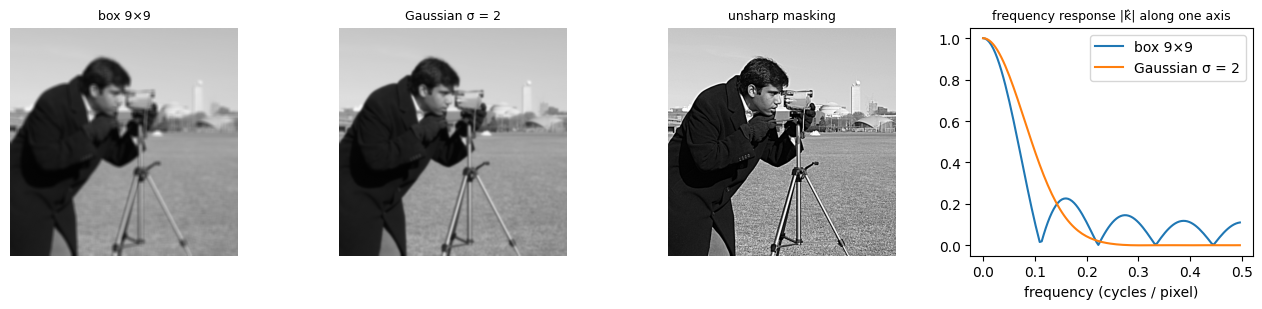

In [2]:
def conv2d(x, k, mode="constant"):
    """'Same'-size 2-D convolution: every output pixel is <flipped kernel, patch>."""
    p, q = k.shape[0] // 2, k.shape[1] // 2
    patches = windows(np.pad(x, ((p, p), (q, q)), mode=mode), k.shape)     # (H, W, kh, kw) view, no copy
    return np.einsum("ijmn,mn->ij", patches, k[::-1, ::-1])

def conv_fft(x, k):
    """Same result through the convolution theorem (zero-padded to the full linear size)."""
    s = (x.shape[0] + k.shape[0] - 1, x.shape[1] + k.shape[1] - 1)
    full = np.real(ifft2(fft2(x, s) * fft2(k, s)))
    p, q = k.shape[0] // 2, k.shape[1] // 2
    return full[p:p + x.shape[0], q:q + x.shape[1]]

def gaussian(s):
    r = int(3 * s); g = np.exp(-np.arange(-r, r + 1) ** 2 / (2 * s * s))
    return np.outer(g, g) / g.sum() ** 2

box, gauss = np.ones((9, 9)) / 81, gaussian(2)
blur_box, blur_gauss = conv2d(cam, box, "reflect"), conv2d(cam, gauss, "reflect")   # mirror padding: no dark border
sharp = cam + 1.5 * (cam - blur_gauss)                   # unsharp masking: boost what the blur removes

from scipy.ndimage import convolve
g = gauss.sum(1, keepdims=True)                          # the 1-D factor, as a column
assert np.allclose(conv2d(cam, gauss), conv_fft(cam, gauss))                      # direct = Fourier (zero padding)
assert np.allclose(blur_gauss, convolve(cam, gauss, mode="mirror"))               # = scipy, same padding
assert np.allclose(blur_gauss, conv2d(conv2d(cam, g, "reflect"), g.T, "reflect")) # separable: two 1-D passes

fig, ax = plt.subplots(1, 4, figsize=(13, 3.2))
for a, im, t in zip(ax, (blur_box, blur_gauss, sharp), ("box 9×9", "Gaussian σ = 2", "unsharp masking")):
    a.imshow(im, cmap="gray", vmin=0, vmax=1); a.set_title(t); a.axis("off")
freq = fftfreq(256)[:128]
for k, name in ((box, "box 9×9"), (gauss, "Gaussian σ = 2")):
    ax[3].plot(freq, np.abs(fft2(k, (256, 256))[0, :128]), label=name)
ax[3].set(xlabel="frequency (cycles / pixel)", title="frequency response |k̂| along one axis"); ax[3].legend()
plt.tight_layout(); plt.show()

The box filter's response is a sinc: its side lobes let high frequencies through with a flipped sign, which shows up as ringing. The Gaussian's response is a Gaussian — no side lobes — and it is the only kernel that is both isotropic and separable, so a $k \times k$ blur costs $2k$ operations per pixel instead of $k^2$.

## 2. Erosion and dilation — and max-pooling

Replace the weighted sum by a min or a max over a neighbourhood $B$, the *structuring element*: erosion $(x \ominus B)[p] = \min_{b \in B} x[p+b]$, dilation $(x \oplus B)[p] = \max_{b \in B} x[p+b]$. On a binary image erosion shrinks shapes and dilation grows them; an opening (erode, then dilate) removes specks smaller than $B$, a closing (dilate, then erode) fills holes smaller than $B$. Non-linear, but the same sliding window as §1.

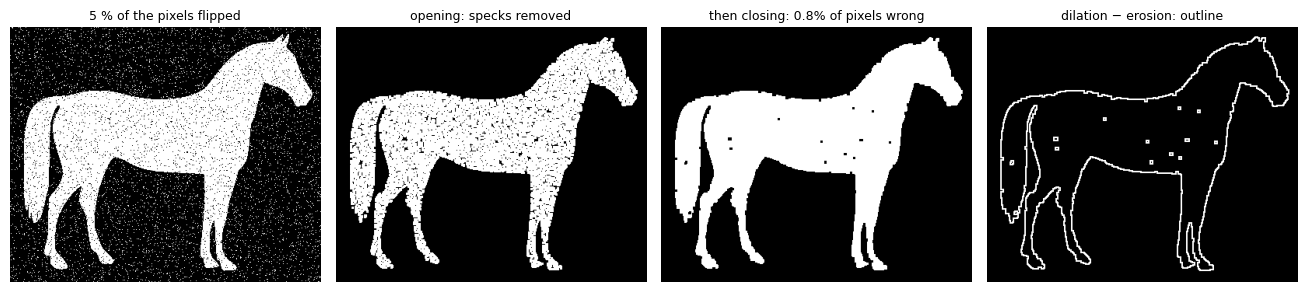

In [3]:
def erode(x, B):
    p, q = B.shape[0] // 2, B.shape[1] // 2
    return windows(np.pad(x, ((p, p), (q, q)), mode="edge"), B.shape)[..., B].min(-1)

def dilate(x, B):
    p, q = B.shape[0] // 2, B.shape[1] // 2
    return windows(np.pad(x, ((p, p), (q, q)), mode="edge"), B.shape)[..., B].max(-1)

opening = lambda x, B: dilate(erode(x, B), B)
closing = lambda x, B: erode(dilate(x, B), B)

B = np.ones((3, 3), bool)
horse = ~data.horse()                                    # True on the horse
noisy = horse ^ (rng.random(horse.shape) < 0.05)         # flip 5 % of the pixels
clean = closing(opening(noisy, B), B)
show([noisy, opening(noisy, B), clean, dilate(clean, B) & ~erode(clean, B)],
     ["5 % of the pixels flipped", "opening: specks removed", f"then closing: {(clean != horse).mean():.1%} of pixels wrong",
      "dilation − erosion: outline"], h=2.7)

sq = np.zeros((40, 40), bool); sq[10:30, 10:30] = True
assert erode(sq, B).sum() == 18 ** 2 and dilate(sq, B).sum() == 22 ** 2       # a 20×20 square loses / gains 1 px
assert np.array_equal(erode(noisy, B), ~dilate(~noisy, B))                      # duality
o = opening(noisy, B)
assert np.array_equal(opening(o, B), o)                                         # opening is idempotent
assert (o <= noisy).all() and (noisy <= closing(noisy, B)).all()                # opening ⊆ x ⊆ closing
from scipy.ndimage import grey_erosion
assert np.allclose(erode(cam, np.ones((5, 5), bool)), grey_erosion(cam, size=5, mode="nearest"))

**Max-pooling is a dilation.** With a 2×2 structuring element anchored at the pixel, a grey-level dilation followed by keeping one pixel in two (stride 2) is exactly the 2×2 max-pooling of a CNN, the layer that makes features robust to small shifts.

In [4]:
B_pool = np.zeros((3, 3), bool); B_pool[1:, 1:] = True               # offsets {0, 1}²
pooled = cam.reshape(256, 2, 256, 2).max((1, 3))                     # 2×2 max-pooling, stride 2
assert np.array_equal(dilate(cam, B_pool)[::2, ::2], pooled)

## 3. Sobel — and learning it back

Edges are where the intensity changes fast, i.e. where the gradient is large. Sobel estimates the horizontal derivative by a central difference smoothed across the other direction, $G_x = \tfrac18\,[1,2,1]^\top[1,0,-1]$ (written flipped, since the convolution flips it back). The magnitude $\sqrt{g_x^2 + g_y^2}$ gives the edge strength, $\operatorname{atan2}(g_y, g_x)$ its orientation.

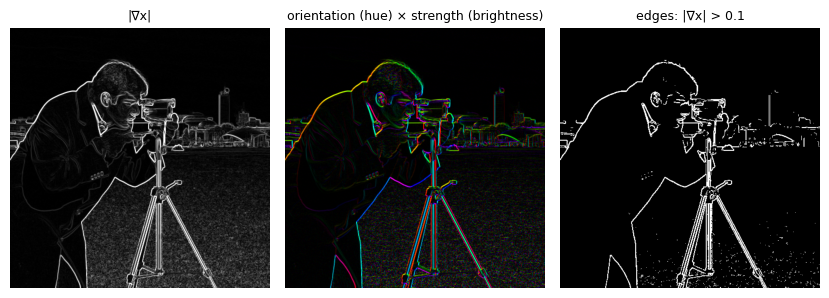

In [5]:
Gx = np.outer([1, 2, 1], [1, 0, -1]) / 8; Gy = Gx.T
gx, gy = conv2d(cam, Gx, "edge"), conv2d(cam, Gy, "edge")    # edge padding: no fake edges along the border
mag, ang = np.hypot(gx, gy), np.arctan2(gy, gx)
edges = mag > 0.1

i, j = np.mgrid[:64, :64]
ramp = 0.3 * j - 0.7 * i
assert np.allclose(conv2d(ramp, Gx)[1:-1, 1:-1], 0.3) and np.allclose(conv2d(ramp, Gy)[1:-1, 1:-1], -0.7)  # exact slopes

from matplotlib.colors import hsv_to_rgb
orient = hsv_to_rgb(np.stack([(ang + np.pi) / (2 * np.pi), np.ones_like(ang), np.clip(mag / 0.25, 0, 1)], -1))
show([mag / 0.25, orient, edges], ["|∇x|", "orientation (hue) × strength (brightness)", "edges: |∇x| > 0.1"], h=2.8)

**Learning Sobel back.** Keep only input/output pairs $(x,\ G_x * x)$ and fit a 3×3 kernel $w$ by gradient descent on $\tfrac1N\|w * x - y\|^2$. The gradient with respect to $w$ is the correlation between the input patches and the residual — the backward pass of a convolution layer. This is a one-layer, linear, bias-free CNN, and it recovers $G_x$ to machine precision. Trained on natural images, the first layer of a real CNN ends up with filters of this kind: oriented edge detectors.

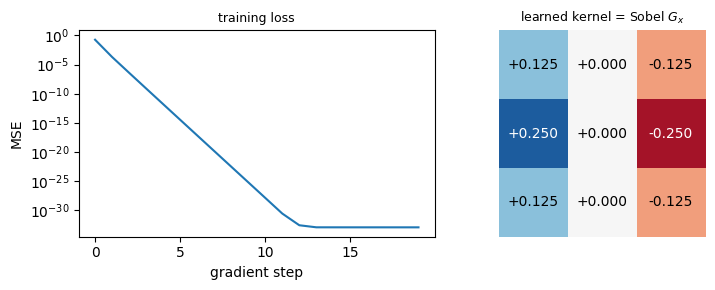

In [6]:
x = rng.standard_normal((128, 128))                       # white noise excites every frequency
y = conv2d(x, Gx)
X = windows(np.pad(x, 1), (3, 3))[..., ::-1, ::-1]        # flipped patches: y = Σ X·w
w, lr, losses = np.zeros((3, 3)), 0.5, []
for step in range(20):
    r = np.einsum("ijmn,mn->ij", X, w) - y                    # forward pass → residual
    losses.append(np.mean(r ** 2))
    w -= lr * 2 * np.einsum("ijmn,ij->mn", X, r) / r.size    # backward pass: ∂loss/∂w
assert np.abs(w - Gx).max() < 1e-6

fig, ax = plt.subplots(1, 2, figsize=(8, 3))
ax[0].semilogy(losses); ax[0].set(xlabel="gradient step", ylabel="MSE", title="training loss")
ax[1].imshow(w, cmap="RdBu", vmin=-0.3, vmax=0.3); ax[1].set_title("learned kernel = Sobel $G_x$"); ax[1].axis("off")
for (m, n), val in np.ndenumerate(np.round(w, 3) + 0):
    ax[1].text(n, m, f"{val:+.3f}", ha="center", va="center", color="w" if abs(val) > 0.2 else "k")
plt.tight_layout(); plt.show()

## 4. Hough transform

A line is the set of points with $x\cos\theta + y\sin\theta = \rho$. Each edge pixel votes for every $(\rho, \theta)$ it could belong to — a sinusoid in parameter space — and lines show up as peaks of the vote accumulator. Peaks are found with the dilation of §2: a cell is a local maximum when it equals the max over its neighbourhood (non-maximum suppression).

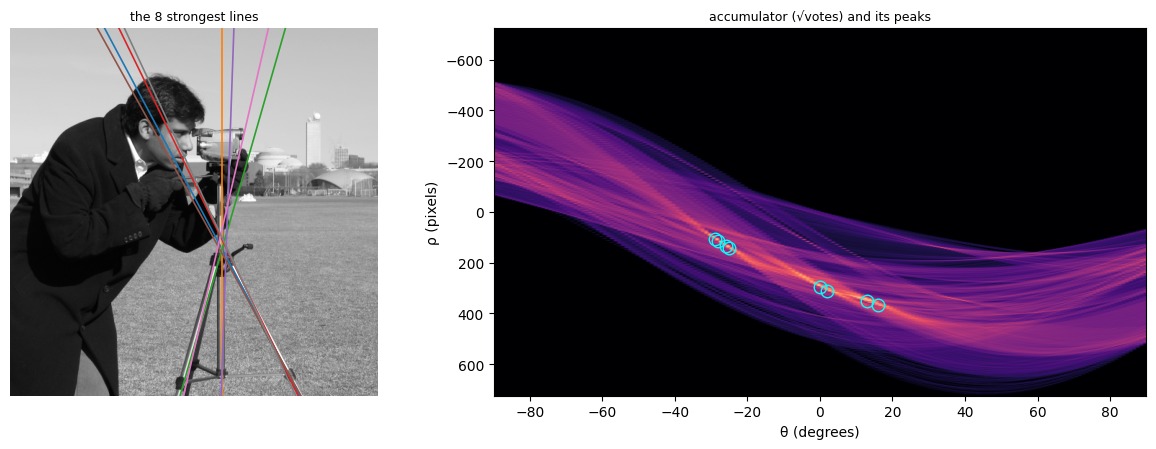

In [7]:
def hough(edges, thetas=np.linspace(-np.pi / 2, np.pi / 2, 180, endpoint=False)):
    off = int(np.ceil(np.hypot(*edges.shape)))                           # ρ ∈ [−off, off]
    y, x = np.nonzero(edges)
    rho = x[:, None] * np.cos(thetas) + y[:, None] * np.sin(thetas)     # one sinusoid per edge pixel
    r = (np.sign(rho) * np.floor(np.abs(rho) + 0.5)).astype(int) + off
    acc = np.bincount((r * len(thetas) + np.arange(len(thetas))).ravel(), minlength=(2 * off + 1) * len(thetas))
    return acc.reshape(2 * off + 1, len(thetas)), np.arange(-off, off + 1), thetas

def peaks(acc, n, size=15):
    """The n highest local maxima (a separable dilation keeps the memory low)."""
    m = dilate(dilate(acc, np.ones((size, 1), bool)), np.ones((1, size), bool))
    cand = np.argwhere((acc == m) & (acc > 0))
    return cand[np.argsort(-acc[tuple(cand.T)], kind="stable")][:n]

# Synthetic check: 4 known lines on a 128×128 canvas
yy, xx = np.mgrid[:128, :128]
truth = [(40, -30), (90, 60), (70, 0), (-30, -45)]                        # (ρ in pixels, θ in degrees)
lines = [np.abs(xx * np.cos(np.deg2rad(t)) + yy * np.sin(np.deg2rad(t)) - r) < 0.5 for r, t in truth]
acc, rhos, thetas = hough(np.logical_or.reduce(lines))
found = {(rhos[i], round(np.rad2deg(thetas[j]))): acc[i, j] for i, j in peaks(acc, 4)}
assert found == {t: line.sum() for t, line in zip(truth, lines)}         # every line, with one vote per pixel

from skimage.transform import hough_line
acc, rhos, thetas = hough(edges)                                          # Sobel edges of the cameraman
assert np.array_equal(acc, hough_line(edges)[0])                          # bit-identical to scikit-image

pk = peaks(acc, 8)
fig, ax = plt.subplots(1, 2, figsize=(12, 4.6), gridspec_kw={"width_ratios": [1, 1.5]})
ax[0].imshow(cam, cmap="gray")
t_ = np.array([-1000, 1000])
for i, j in pk:
    c, s = np.cos(thetas[j]), np.sin(thetas[j])
    ax[0].plot(rhos[i] * c - t_ * s, rhos[i] * s + t_ * c, lw=1.2)
ax[0].set(xlim=(0, 511), ylim=(511, 0), title="the 8 strongest lines"); ax[0].axis("off")
ax[1].imshow(np.sqrt(acc), cmap="magma", aspect="auto", extent=(-90, 90, rhos[-1], rhos[0]))
ax[1].plot(np.rad2deg(thetas[pk[:, 1]]), rhos[pk[:, 0]], "o", mfc="none", mec="cyan", ms=9)
ax[1].set(xlabel="θ (degrees)", ylabel="ρ (pixels)", title="accumulator (√votes) and its peaks")
plt.tight_layout(); plt.show()

*Deep learning:* the Deep Hough Transform (Zhao et al., 2020) runs this voting inside a network, on learned feature maps instead of thresholded edges, and learns to read the peaks.

## 5. Deblurring and denoising: Tikhonov, then Wiener

**Model.** $y = h * x + n$, with a known blur $h$ and white noise of variance $\sigma^2$. With periodic boundaries the DFT diagonalises the convolution, so the problem splits into one scalar equation per frequency, $Y(\omega) = H(\omega)X(\omega) + N(\omega)$. The naive inverse $Y/H$ divides the noise by $|H|$, which is tiny at high frequencies: the problem is ill-posed.

**Tikhonov.** Trade data fidelity against a penalty on an operator $L$ (the identity, or the gradient):
$$\hat x = \arg\min_x \; \|h * x - y\|^2 + \lambda\,\|Lx\|^2 .$$
By Parseval the objective is $\sum_\omega |HX - Y|^2 + \lambda|L|^2|X|^2$, separable in $\omega$. Setting its derivative with respect to $\bar X$ to zero, $\bar H(HX - Y) + \lambda|L|^2 X = 0$:
$$\hat X_{\text{Tik}} = \frac{\bar H\,Y}{|H|^2 + \lambda|L|^2}.$$

**Wiener.** Now treat $x$ as random with power spectrum $S_x(\omega)$, independent of the noise (spectrum $S_n = \sigma^2$), and look for the linear filter $\hat X = WY$ with the smallest expected error. Per frequency,
$$\mathbb E\,|X - WY|^2 = |1 - WH|^2 S_x + |W|^2 S_n ,$$
a quadratic in $W$, minimal for
$$W = \frac{\bar H}{|H|^2 + S_n / S_x}.$$

**Wiener is Tikhonov** with a frequency-dependent penalty, $\lambda|L(\omega)|^2 = S_n/S_x(\omega)$: the noise-to-signal ratio. Natural images have $S_x \approx c\,|\omega|^{-\alpha}$ with $\alpha \approx 2$. For $\alpha = 2$, $S_n/S_x = \sigma^2|\omega|^2/c$, and since $|L(\omega)|^2 \approx |\omega|^2$ for the discrete gradient, that is Tikhonov with $L = \nabla$ and $\lambda = \sigma^2/c$. The knob $\lambda$ is no longer tuned: it is set by the noise level and the statistics of natural images.

In [8]:
def otf(k, shape):
    """Transfer function H(ω) of a small kernel centred at the origin (psf2otf)."""
    kp = np.pad(k, [(0, s - n) for s, n in zip(shape, k.shape)])
    return fft2(np.roll(kp, [-(n // 2) for n in k.shape], axis=(0, 1)))

def grad2(shape):
    """|L(ω)|² for L = the discrete gradient (forward differences)."""
    ky, kx = np.meshgrid(fftfreq(shape[0]), fftfreq(shape[1]), indexing="ij")
    return 4 * np.sin(np.pi * kx) ** 2 + 4 * np.sin(np.pi * ky) ** 2

def tikhonov(y, H, lam, L2):
    return np.real(ifft2(np.conj(H) * fft2(y) / (np.abs(H) ** 2 + lam * L2)))

def wiener(y, H, Sx, Sn):
    return tikhonov(y, H, 1, Sn / Sx)                        # Wiener = Tikhonov with λ|L|² = S_n / S_x

h, sigma = gaussian(1.5), 0.05
y = conv2d(cam, h, "wrap") + sigma * rng.standard_normal(cam.shape)          # periodic blur + noise
H, L2 = otf(h, cam.shape), grad2(cam.shape)
assert np.allclose(conv2d(cam, h, "wrap"), np.real(ifft2(H * fft2(cam))))    # circular convolution = product by H

# The Fourier formula is the exact minimiser: dense solve of the normal equations on a 16×16 patch
ys, lam = y[:16, :16], 0.1
normal = lambda v: (conv2d(conv2d(v, h, "wrap"), h[::-1, ::-1], "wrap")                           # HᵀH v
                    + lam * (4 * v - sum(np.roll(v, s, a) for s in (1, -1) for a in (0, 1))))    # + λ LᵀL v
A = np.stack([normal(e.reshape(16, 16)).ravel() for e in np.eye(256)], 1)
x_dense = np.linalg.solve(A, conv2d(ys, h[::-1, ::-1], "wrap").ravel()).reshape(16, 16)
assert np.allclose(x_dense, tikhonov(ys, otf(h, (16, 16)), lam, grad2((16, 16))))

**A prior from the observation alone.** The degraded image has spectrum $S_y = |H|^2 S_x + \sigma^2$, so wherever the signal dominates the noise, $S_x \approx (S_y - \sigma^2)/|H|^2$. Fitting $c\,|\omega|^{-\alpha}$ on ring averages gives a Wiener filter that needs neither the clean image nor a tuned $\lambda$. For comparison: Tikhonov swept over $\lambda$ and scored against the clean image (which is cheating), and the *oracle* Wiener, built on the true spectrum of the clean image — a ceiling.

degraded 23.49 dB | naive inverse -112 dB | best Tikhonov L=I 24.21 dB | best L=∇ 26.62 dB (λ = 0.2)
Wiener with the fitted prior (α = 2.60): 26.64 dB | oracle Wiener 27.13 dB


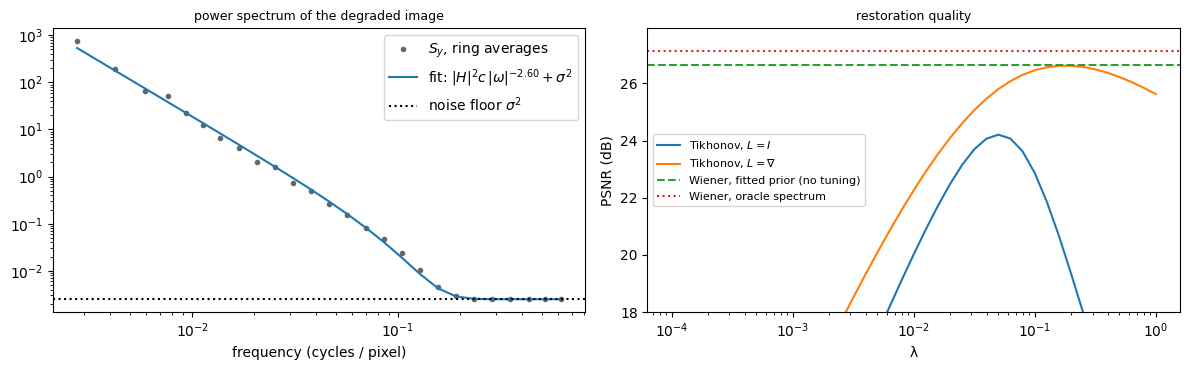

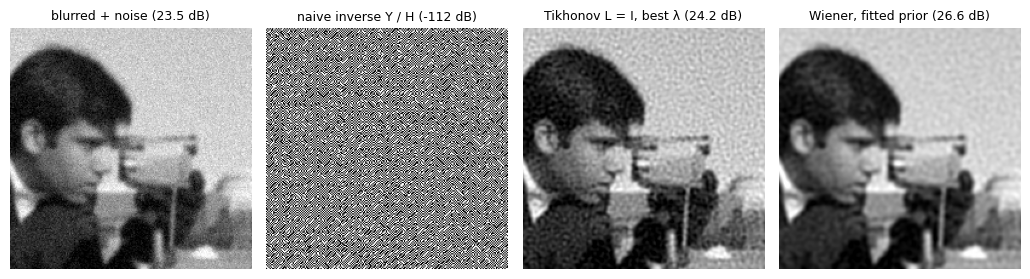

In [9]:
N = cam.size
k = np.hypot(*np.meshgrid(fftfreq(512), fftfreq(512), indexing="ij"))       # radial frequency (cycles / pixel)
Sy = np.abs(fft2(y)) ** 2 / N
rings = np.digitize(k, np.logspace(-2.7, -0.15, 30)).ravel()                # log-spaced rings, 0 = lowest
count = np.bincount(rings)
radial = lambda S: (np.bincount(rings, S.ravel()) / np.maximum(count, 1))[1:][count[1:] > 0]
kr, Syr, H2r = radial(k), radial(Sy), radial(np.abs(H) ** 2)
fit = Syr > 4 * sigma ** 2                                                   # signal-dominated rings
slope, logc = np.polyfit(np.log(kr[fit]), np.log((Syr[fit] - sigma ** 2) / H2r[fit]), 1)
alpha, c = -slope, np.exp(logc)
Sx_model = c * np.maximum(k, 1e-9) ** -alpha                                 # S_x → ∞ at DC: the mean is free

lams = np.logspace(-4, 0, 41)
psnr_I = [psnr(tikhonov(y, H, l, 1), cam) for l in lams]
psnr_grad = [psnr(tikhonov(y, H, l, L2), cam) for l in lams]
x_naive = tikhonov(y, H, 0, 1)
x_I = tikhonov(y, H, lams[np.argmax(psnr_I)], 1)
x_wiener = wiener(y, H, Sx_model, sigma ** 2)
x_oracle = wiener(y, H, np.abs(fft2(cam)) ** 2 / N, sigma ** 2)
print(f"degraded {psnr(y, cam):.2f} dB | naive inverse {psnr(x_naive, cam):.0f} dB | best Tikhonov L=I {max(psnr_I):.2f} dB"
      f" | best L=∇ {max(psnr_grad):.2f} dB (λ = {lams[np.argmax(psnr_grad)]:.2g})\n"
      f"Wiener with the fitted prior (α = {alpha:.2f}): {psnr(x_wiener, cam):.2f} dB | oracle Wiener {psnr(x_oracle, cam):.2f} dB")
assert psnr(x_wiener, cam) > max(psnr_grad) - 0.1        # no tuning, as good as the best hand-tuned λ
assert psnr(x_oracle, cam) > max(psnr_I + psnr_grad)     # the oracle is a ceiling

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
ax[0].loglog(kr, Syr, ".", color="0.4", label="$S_y$, ring averages")
ax[0].loglog(kr, H2r * c * kr ** -alpha + sigma ** 2, label=rf"fit: $|H|^2 c\,|\omega|^{{-{alpha:.2f}}} + \sigma^2$")
ax[0].axhline(sigma ** 2, ls=":", color="k", label=r"noise floor $\sigma^2$")
ax[0].set(xlabel="frequency (cycles / pixel)", title="power spectrum of the degraded image"); ax[0].legend()
ax[1].semilogx(lams, psnr_I, label="Tikhonov, $L = I$")
ax[1].semilogx(lams, psnr_grad, label=r"Tikhonov, $L = \nabla$")
ax[1].axhline(psnr(x_wiener, cam), ls="--", color="C2", label="Wiener, fitted prior (no tuning)")
ax[1].axhline(psnr(x_oracle, cam), ls=":", color="C3", label="Wiener, oracle spectrum")
ax[1].set(xlabel="λ", ylabel="PSNR (dB)", ylim=(18, None), title="restoration quality"); ax[1].legend(loc="center left", fontsize=8)
plt.tight_layout(); plt.show()

crop = np.s_[50:250, 170:370]
show([im[crop] for im in (y, x_naive, x_I, x_wiener)],
     [f"blurred + noise ({psnr(y, cam):.1f} dB)", f"naive inverse Y / H ({psnr(x_naive, cam):.0f} dB)",
      f"Tikhonov L = I, best λ ({max(psnr_I):.1f} dB)", f"Wiener, fitted prior ({psnr(x_wiener, cam):.1f} dB)"], h=2.6)

*Deep learning:* with $L = I$, Tikhonov is ridge regression — weight decay. In Bayesian terms $\lambda\|Lx\|^2$ is a Gaussian prior on the image and both filters are MAP estimates: the whole restoration is one fixed linear layer whose weights are set by that prior. Learned denoisers keep the structure and learn the prior from examples.

## 6. Mini-project: refocusing a photograph

**Image → depth → 3-D object → reprojection through a lens**, with a blur that depends on each point's distance to a new focal plane.

**Depth — the one imported algorithm.** MiDaS v2.1 small (Ranftl et al.) is a CNN that predicts relative *inverse* depth from a single image. It runs through `onnxruntime` (CPU, no PyTorch); the weights (67 MB) are downloaded once and cached. The scene, the Middlebury motorcycle, comes with a ground-truth disparity map measured by stereo — disparity is proportional to $1/Z$, the same quantity — to check the prediction against.

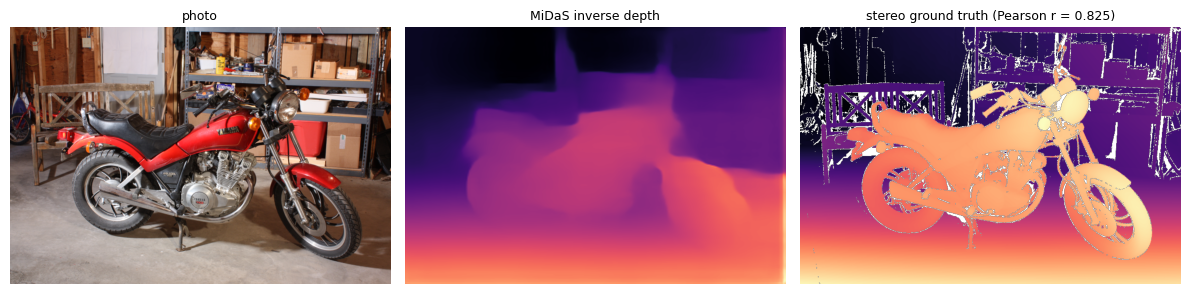

In [10]:
import pooch, onnxruntime as ort
from skimage.transform import resize

weights = pooch.retrieve("https://github.com/isl-org/MiDaS/releases/download/v2_1/model-small.onnx",
                         "sha256:2d8c6cb8f415229daf1eb041024208e2608c9f98e17c81cc7c6ecb449c56fd58")
net = ort.InferenceSession(weights, providers=["CPUExecutionProvider"])

def inverse_depth(img):
    """MiDaS: RGB image in [0, 1] → relative inverse depth (larger = closer), same size as the image."""
    x = resize(img, (256, 256), order=3, anti_aliasing=True)
    x = (x - [0.485, 0.456, 0.406]) / [0.229, 0.224, 0.225]                       # ImageNet normalisation
    d = net.run(None, {"0": x.transpose(2, 0, 1)[None].astype(np.float32)})[0][0]
    return resize(d, img.shape[:2], order=3)

left, _, disp_gt = data.stereo_motorcycle()
img = img_as_float(left)
D = inverse_depth(img)
known = np.isfinite(disp_gt)
r = np.corrcoef(D[known], disp_gt[known])[0, 1]
assert r > 0.8
show([img, D, np.where(known, disp_gt, np.nan)],
     ["photo", "MiDaS inverse depth", f"stereo ground truth (Pearson r = {r:.3f})"], h=2.7, cmap="magma", vmin=None, vmax=None)

**Lifting to 3-D.** MiDaS is only defined up to scale and shift, so fix a plausible range: normalise it to $[0, 1]$ and map it linearly in $1/Z$ onto $Z \in [1.5, 4.5]$ m. A pinhole camera of focal length $f$ pixels back-projects pixel $(u, v)$ to $P = \big((u - c_u)Z/f,\ (v - c_v)Z/f,\ Z\big)$, and projecting $P$ gives the pixel back — an exact check. Moving the camera and splatting the points with a z-buffer (the nearest point wins) shows that the photo has become a 3-D object; the white holes are what the original viewpoint could not see.

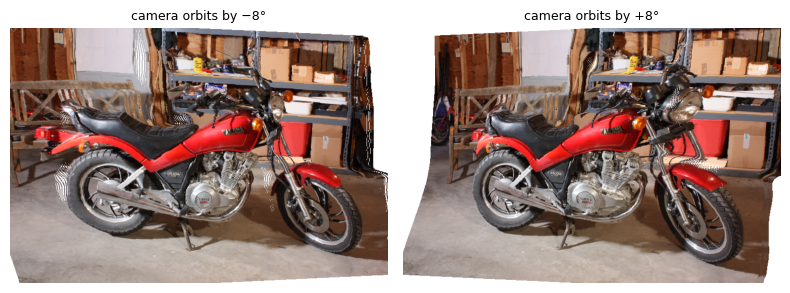

In [11]:
height, width = D.shape
f = width                                                              # focal length in pixels (~53° field of view)
Dn = (D - D.min()) / (D.max() - D.min())
Z = 1 / (Dn / 1.5 + (1 - Dn) / 4.5)                                    # 1.5 m (nearest) … 4.5 m, linear in 1/Z
v, u = np.mgrid[:height, :width]
P = np.stack([(u - width / 2) * Z / f, (v - height / 2) * Z / f, Z], -1)   # one 3-D point per pixel

def project(P, R=np.eye(3), t=np.zeros(3)):
    """Pinhole camera with pose (R, t): 3-D points → pixel coordinates and depth."""
    Pc = P @ R.T + t
    return f * Pc[..., 0] / Pc[..., 2] + width / 2, f * Pc[..., 1] / Pc[..., 2] + height / 2, Pc[..., 2]

pu, pv, _ = project(P)
assert np.allclose(pu, u) and np.allclose(pv, v)                       # projection ∘ back-projection = identity

def render(P, colors, R, t):
    """Z-buffer splatting: each point covers 2×2 pixels and the nearest one wins; holes stay white."""
    pu, pv, pz = (a.ravel() for a in project(P, R, t))
    ui = (np.floor(pu).astype(int)[:, None] + [0, 1, 0, 1]).ravel()
    vi = (np.floor(pv).astype(int)[:, None] + [0, 0, 1, 1]).ravel()
    pz, col = np.repeat(pz, 4), np.repeat(colors.reshape(-1, 3), 4, axis=0)
    ok = (ui >= 0) & (ui < width) & (vi >= 0) & (vi < height) & (pz > 0)
    pix, pz, col = vi[ok] * width + ui[ok], pz[ok], col[ok]
    order = np.lexsort((pz, pix))                                      # by pixel, then nearest first
    first = order[np.unique(pix[order], return_index=True)[1]]
    out = np.ones((height * width, 3)); out[pix[first]] = col[first]
    return out.reshape(height, width, 3)

def orbit(deg, pivot):
    """Camera orbiting the scene about a vertical axis through `pivot`."""
    a = np.deg2rad(deg)
    R = np.array([[np.cos(a), 0, np.sin(a)], [0, 1, 0], [-np.sin(a), 0, np.cos(a)]])
    return R, pivot - R @ pivot

pivot = np.array([0, 0, np.median(Z)])
show([render(P, img, *orbit(d, pivot)) for d in (-8, 8)], ["camera orbits by −8°", "camera orbits by +8°"], h=2.7)

**Thin-lens blur.** A lens of aperture $A$ and focal length $F$, focused at distance $Z_f$, images a point at depth $Z$ as a disc — the circle of confusion — of diameter
$$c = \frac{A F}{Z_f - F}\cdot\frac{|Z - Z_f|}{Z} \;\approx\; K\,\Big|\frac1Z - \frac1{Z_f}\Big| \qquad (F \ll Z_f),$$
linear in *inverse* depth, which is exactly what the network predicts. Rendering: slice the scene into layers of equal width in $1/Z$, blur each layer with a disc of its own diameter (the FFT convolution of §1), and composite from back to front with the "over" operator, so a blurred foreground spills over the background and never the reverse. Blurring happens in linear light (sRGB decoded with a 2.2 gamma), which is what turns highlights into bright discs.

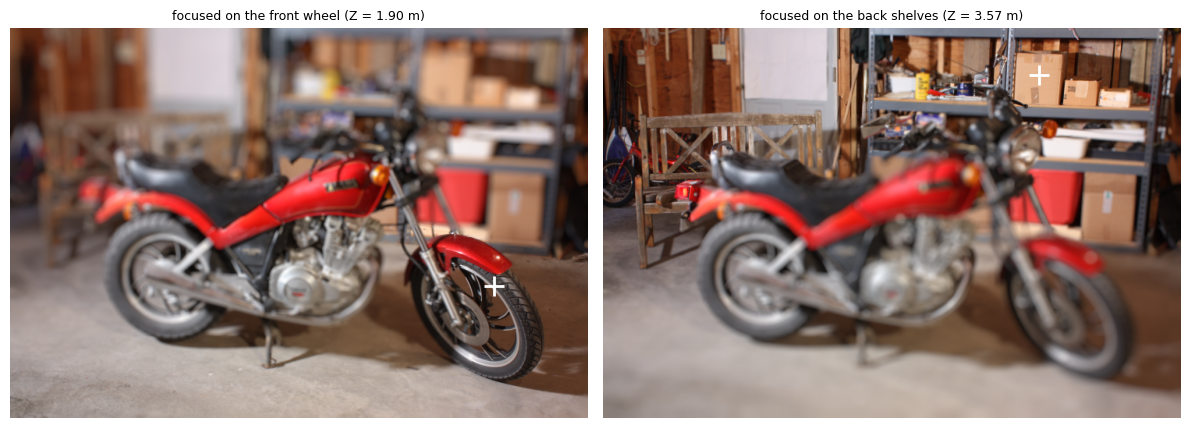

focused on the front wheel: that patch is unchanged, the back shelves keeps 38% of its sharpness
focused on the back shelves: that patch is unchanged, the front wheel keeps 16% of its sharpness


In [12]:
def disk(r):
    """Anti-aliased disc of radius r pixels, normalised to sum 1."""
    R = int(np.ceil(r)); yy, xx = np.mgrid[-R:R + 1, -R:R + 1]
    k = np.clip(r + 0.5 - np.hypot(xx, yy), 0, 1)
    return k / k.sum()

def refocus(img, P, z_focus, K=70, n_layers=16):
    """Reproject the point cloud through a thin lens focused at z_focus (K: blur strength, in pixels × metres)."""
    lin = img ** 2.2                                                     # ≈ linear light
    pu, pv, pz = project(P)
    ui, vi, inv = np.rint(pu).astype(int), np.rint(pv).astype(int), 1 / pz
    edges = np.linspace(inv.min(), inv.max(), n_layers + 1)
    layer = np.clip(np.digitize(inv, edges) - 1, 0, n_layers - 1)       # 0 = farthest
    out, acc = np.zeros_like(img), np.zeros(img.shape[:2])
    for l in range(n_layers):                                            # back to front
        m = layer == l
        if not m.any():
            continue
        rgba = np.zeros(img.shape[:2] + (4,))
        rgba[vi[m], ui[m]] = np.c_[lin[m], np.ones(m.sum())]             # premultiplied colour + alpha
        coc = K * abs((edges[l] + edges[l + 1]) / 2 - 1 / z_focus)      # circle of confusion (diameter, px)
        b = np.stack([conv_fft(rgba[..., ch], disk(coc / 2)) for ch in range(4)], -1)
        out = b[..., :3] + (1 - b[..., 3:]) * out                        # "over" compositing
        acc = b[..., 3] + (1 - b[..., 3]) * acc
    return np.clip(out / np.maximum(acc, 1e-8)[..., None], 0, 1) ** (1 / 2.2)

assert np.allclose(refocus(img, P, 2.0, K=0), img, atol=1e-6)            # zero aperture = pinhole: the photo comes back

focus = {"front wheel": (620, 330), "back shelves": (560, 60)}            # (u, v) in pixels
renders = {}
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
for a, (name, (fu, fv)) in zip(ax, focus.items()):
    zf = np.median(Z[fv - 4:fv + 5, fu - 4:fu + 5])
    renders[name] = refocus(img, P, zf)
    a.imshow(renders[name]); a.plot(fu, fv, "w+", ms=14, mew=2)
    a.set_title(f"focused on the {name} (Z = {zf:.2f} m)"); a.axis("off")
plt.tight_layout(); plt.show()

patch = lambda im, uv, r=10: im[uv[1] - r:uv[1] + r + 1, uv[0] - r:uv[0] + r + 1]
sharpness = lambda im: np.hypot(*np.gradient(im.mean(-1))).mean()          # mean gradient magnitude
for name, other in zip(focus, list(focus)[::-1]):
    kept = sharpness(patch(renders[name], focus[other])) / sharpness(patch(img, focus[other]))
    assert np.allclose(patch(renders[name], focus[name]), patch(img, focus[name]))   # the focal plane is left untouched
    assert kept < 0.5                                                                  # the other point is visibly blurred
    print(f"focused on the {name}: that patch is unchanged, the {other} keeps {kept:.0%} of its sharpness")

Both renders come from the same photo and the same point cloud; only $Z_f$ changes. The patch at the focus point comes back pixel-exact, the other one loses most of its sharpness. Phone "portrait mode" is this pipeline: a learned depth map, then a synthetic lens.

## 7. Compression: JPEG

JPEG cuts the image into 8×8 blocks and applies the orthonormal DCT-II to each, $F = C B C^\top$ with $C_{uk} = \sqrt{2/8}\;a_u\cos\frac{(2k+1)u\pi}{16}$ ($a_0 = 1/\sqrt2$, $a_u = 1$ otherwise). Natural images put most of their energy in the low frequencies (the $|\omega|^{-\alpha}$ spectrum of §5), so dividing by a quantisation table that grows with frequency and rounding sends most coefficients to zero. That rounding is the only lossy step: the quality factor $q$ scales the table, and the entropy coder (run lengths + Huffman, left to Pillow here) turns the zeros into saved bytes.

 q   zeros  bits/pixel  PSNR ours  PSNR libjpeg
 5   97.6%       0.158      26.32         26.32
10   96.3%       0.229      28.43         28.43
25   92.5%       0.425      30.81         30.81
50   88.0%       0.673      32.60         32.60
75   81.3%       1.052      35.08         35.08
95   57.3%       2.595      45.09         45.08


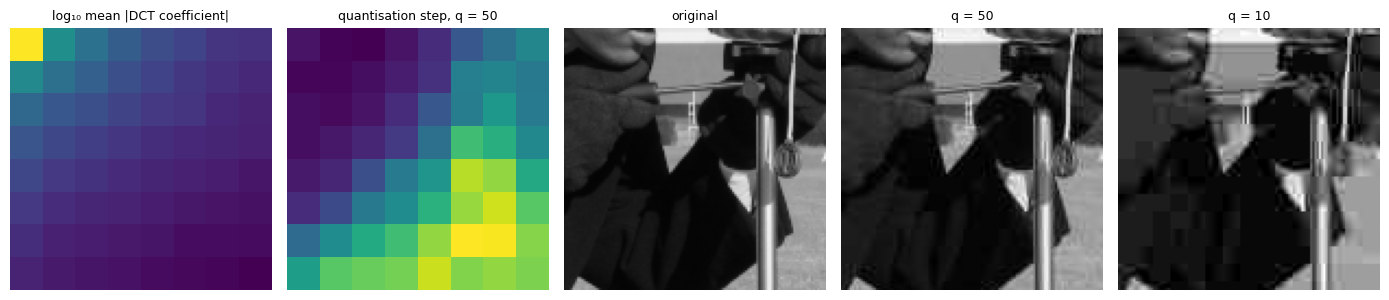

In [13]:
n8 = np.arange(8)
C = np.sqrt(2 / 8) * np.cos(np.pi * (2 * n8[None, :] + 1) * n8[:, None] / 16); C[0] /= np.sqrt(2)
Q50 = np.array([[16, 11, 10, 16, 24, 40, 51, 61], [12, 12, 14, 19, 26, 58, 60, 55],
                [14, 13, 16, 24, 40, 57, 69, 56], [14, 17, 22, 29, 51, 87, 80, 62],
                [18, 22, 37, 56, 68, 109, 103, 77], [24, 35, 55, 64, 81, 104, 113, 92],
                [49, 64, 78, 87, 103, 121, 120, 101], [72, 92, 95, 98, 112, 100, 103, 99]])   # luminance, Annex K

def qtable(q):
    """IJG quality scaling, the one libjpeg uses."""
    s = 5000 / q if q < 50 else 200 - 2 * q
    return np.clip(np.floor((Q50 * s + 50) / 100), 1, 255)

def jpeg(img8, q):
    """8×8 DCT → quantise → dequantise → inverse DCT. Returns the decoded image and the quantised coefficients."""
    hh, ww = img8.shape
    blocks = img8.reshape(hh // 8, 8, ww // 8, 8).transpose(0, 2, 1, 3) - 128.0
    coef = np.rint(C @ blocks @ C.T / qtable(q))
    rec = C.T @ (coef * qtable(q)) @ C + 128
    return np.clip(np.rint(rec), 0, 255).transpose(0, 2, 1, 3).reshape(hh, ww), coef

from scipy.fft import dctn
blk = rng.random((8, 8))
assert np.allclose(C @ C.T, np.eye(8)) and np.allclose(C @ blk @ C.T, dctn(blk, norm="ortho"))

from PIL import Image
cam8 = data.camera()
print(" q   zeros  bits/pixel  PSNR ours  PSNR libjpeg")
for q in (5, 10, 25, 50, 75, 95):
    dec, coef = jpeg(cam8, q)
    buf = io.BytesIO(); Image.fromarray(cam8).save(buf, "JPEG", quality=q)
    p_ours, p_ref = psnr(dec / 255, cam), psnr(np.asarray(Image.open(buf)) / 255, cam)
    print(f"{q:2d}   {(coef == 0).mean():5.1%}  {8 * len(buf.getvalue()) / cam8.size:10.3f}  {p_ours:9.2f}  {p_ref:12.2f}")
    assert abs(p_ours - p_ref) < 0.05                    # same codec as libjpeg, up to its integer DCT

blocks = cam8.reshape(64, 8, 64, 8).transpose(0, 2, 1, 3) - 128.0
energy = np.abs(C @ blocks @ C.T).mean((0, 1))
crop = np.s_[180:300, 200:320]
fig, ax = plt.subplots(1, 5, figsize=(14, 3))
ax[0].imshow(np.log10(energy)); ax[0].set_title("log₁₀ mean |DCT coefficient|")
ax[1].imshow(qtable(50)); ax[1].set_title("quantisation step, q = 50")
for a, (im, t) in zip(ax[2:], [(cam8, "original"), (jpeg(cam8, 50)[0], "q = 50"), (jpeg(cam8, 10)[0], "q = 10")]):
    a.imshow(im[crop], cmap="gray", vmin=0, vmax=255); a.set_title(t)
for a in ax:
    a.axis("off")
plt.tight_layout(); plt.show()

*Deep learning:* learned codecs (Ballé et al., 2017) replace the DCT with a CNN encoder/decoder and the fixed table with a learned entropy model, trained end-to-end on rate + distortion.

## 8. Bonus: colour and the "HDR" look

**Colorimetry in two lines.** sRGB values are gamma-encoded: a pixel value $V$ stands for the linear light $\ell = \big((V + 0.055)/1.055\big)^{2.4}$ (with a linear segment near black). Light adds linearly, so luminance — perceived brightness — is a weighted sum of *linear* RGB, $Y = 0.2126\,R + 0.7152\,G + 0.0722\,B$; green weighs most because the eye is most sensitive to it.

**Histogram equalisation** maps each value through the cumulative distribution of the image, $v \mapsto F(v)$, so that the output is uniformly distributed: crowded tonal ranges get stretched. Applied to R, G and B separately it changes their ratios and shifts the hues; applied to the luminance only, then scaling linear RGB by $Y_\text{new}/Y$, it keeps every pixel's chromaticity. The local version, CLAHE (contrast-limited adaptive equalisation), gives the familiar "HDR" tone-mapped look.

distance to the uniform distribution 0.0026, max difference with scikit-image 0.0063


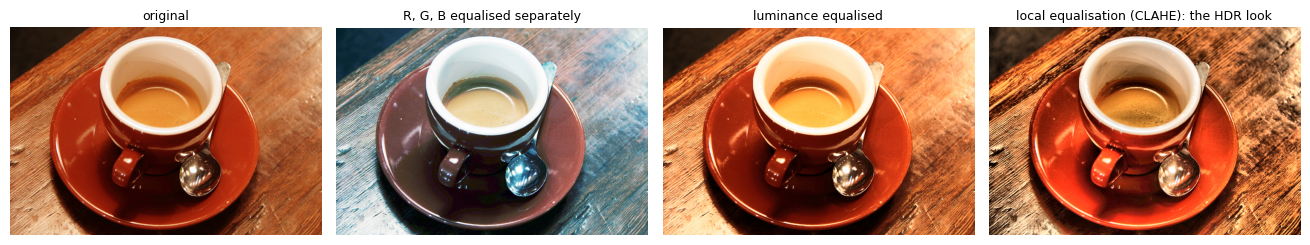

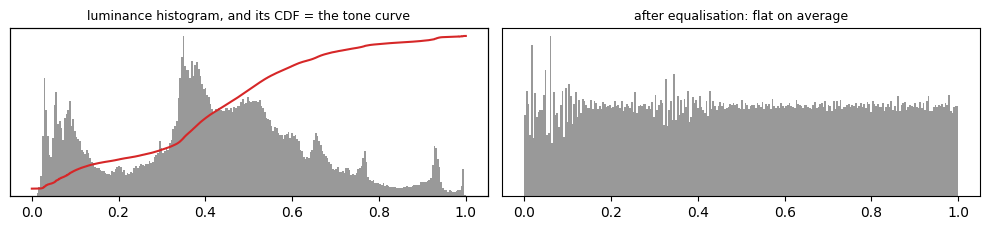

In [14]:
to_linear = lambda V: np.where(V <= 0.04045, V / 12.92, ((V + 0.055) / 1.055) ** 2.4)          # exact sRGB curves
to_srgb = lambda l: np.where(l <= 0.0031308, 12.92 * l, 1.055 * np.maximum(l, 0) ** (1 / 2.4) - 0.055)

def equalize(v, bins=256):
    """Map values through their empirical CDF → uniform histogram."""
    hist, edges = np.histogram(v, bins, (0, 1))
    return np.interp(v, edges[1:], np.cumsum(hist) / v.size)

def with_luminance(lin, Y, Yp_new):
    """Scale linear RGB so that the luminance becomes Yp_new (sRGB-encoded): chromaticity is kept."""
    return to_srgb(np.clip(lin * (to_linear(Yp_new) / np.maximum(Y, 1e-6))[..., None], 0, 1))

rgb = img_as_float(data.coffee())
lin = to_linear(rgb)
Y = lin @ [0.2126, 0.7152, 0.0722]                      # luminance, linear
Yp = to_srgb(Y)                                         # back on the perceptual scale
Yp_eq = equalize(Yp)

from skimage.exposure import equalize_hist, equalize_adapthist
ks = np.abs(np.sort(Yp_eq.ravel()) - np.linspace(0, 1, Yp_eq.size)).max()     # Kolmogorov distance to uniform
diff = np.abs(equalize_hist(Yp) - Yp_eq).max()
print(f"distance to the uniform distribution {ks:.4f}, max difference with scikit-image {diff:.4f}")
assert ks < 0.01 and diff < 0.01
versions = {"original": rgb,
            "R, G, B equalised separately": np.stack([equalize(rgb[..., ch]) for ch in range(3)], -1),
            "luminance equalised": with_luminance(lin, Y, Yp_eq),
            "local equalisation (CLAHE): the HDR look": with_luminance(lin, Y, equalize_adapthist(Yp, clip_limit=0.02))}
show(list(versions.values()), list(versions), h=2.2)

fig, ax = plt.subplots(1, 2, figsize=(10, 2.4))
ax[0].hist(Yp.ravel(), 256, range=(0, 1), color="0.6"); ax[0].set_title("luminance histogram, and its CDF = the tone curve")
cdf = ax[0].twinx(); cdf.plot(np.sort(Yp.ravel()), np.linspace(0, 1, Yp.size), "C3")
ax[1].hist(Yp_eq.ravel(), 256, range=(0, 1), color="0.6"); ax[1].set_title("after equalisation: flat on average")
for a in (*ax, cdf):
    a.set_yticks([])
plt.tight_layout(); plt.show()

*Deep learning:* normalising a distribution is what BatchNorm and LayerNorm do to activations — with two moments instead of the whole CDF. Enhancement networks such as HDRNet (Gharbi et al., 2017) predict local, image-dependent colour transforms: a learned CLAHE.

## Where this leads

Every restoration of §5 is one fixed linear layer whose weights are set by a prior; §3 showed that the same layer can be learned from examples instead. Stack such layers with non-linearities — the max of §2 is one — and train them on (noisy, clean) pairs: that is a CNN denoiser (DnCNN, Zhang et al., 2017).